# House Prices — Advanced Regression Techniques

Real Kaggle competition data (see `data/house_prices/SOURCE.md`): 1460 training
rows, 81 columns, target `SalePrice`. This notebook demonstrates:

- A **full** `EDAAnalyzer` profile (missingness, skew, VIF/multicollinearity,
  target correlations, outliers, the decision-tree feature-importance
  surrogate, automated recommendations) plus `EDAVisualizer` and
  `expect_*` data-quality gates.
- Deep, domain-informed feature engineering (NA-semantic recoding, ratio/age
  features) done *before* the split (deterministic, no leakage) — followed by
  learned preprocessing (imputation, encoding, scaling, correlation-based
  feature selection) done *after* the split, inside a leakage-safe
  `SkyulfPipeline`.
- Hyperparameter tuning via the pipeline's built-in `hyperparameter_tuner`
  wrapper, compared against an untuned baseline and a tree-based model.

Polars + numpy only — no pandas.

In [1]:
import numpy as np
import polars as pl

from skyulf import SkyulfPipeline
from skyulf.profiling.analyzer import EDAAnalyzer
from skyulf.profiling.visualizer import EDAVisualizer
from skyulf.profiling.expect import expect_no_nulls, expect_value_range, ExpectationError

pl.Config.set_tbl_cols(15)

train = pl.read_csv("data/house_prices/train.csv", null_values=["NA"], infer_schema_length=None)
print(train.shape)
train.head()

(1460, 81)


Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,…,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
i64,i64,str,i64,i64,str,str,…,str,i64,i64,i64,str,str,i64
1,60,"""RL""",65,8450,"""Pave""",null,…,null,0,2,2008,"""WD""","""Normal""",208500
2,20,"""RL""",80,9600,"""Pave""",null,…,null,0,5,2007,"""WD""","""Normal""",181500
3,60,"""RL""",68,11250,"""Pave""",null,…,null,0,9,2008,"""WD""","""Normal""",223500
4,70,"""RL""",60,9550,"""Pave""",null,…,null,0,2,2006,"""WD""","""Abnorml""",140000
5,60,"""RL""",84,14260,"""Pave""",null,…,null,0,12,2008,"""WD""","""Normal""",250000


## 1. Full EDA before any feature engineering

`EDAAnalyzer.analyze(target_col="SalePrice")` runs the complete profile in
one call. We read every part of it, not just a summary print — alerts,
recommendations, VIF, target correlations/interactions, outliers, and the
decision-tree feature-importance surrogate.

In [2]:
profile = EDAAnalyzer(train).analyze(target_col="SalePrice")

print(f"Rows: {profile.row_count}  Columns: {profile.column_count}")
print(f"Duplicate rows: {profile.duplicate_rows}")
print(f"Missing cells: {profile.missing_cells_percentage:.2f}%")
print(f"Alerts ({len(profile.alerts)}):")
for a in profile.alerts[:10]:
    print(f"  [{a.severity}] {a.column}: {a.message}")

calculate_correlations: 37 numeric columns exceeds the 20-column cap; truncating to the first 20 by column order (not variance or relevance) and dropping ['HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold'] from the correlation matrix.


calculate_correlations: 38 numeric columns exceeds the 20-column cap; truncating to the first 20 by column order (not variance or relevance) and dropping ['HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice'] from the correlation matrix.


Error in causal discovery: Data correlation matrix is singular. Cannot run fisherz test. Please check your data.


Rows: 1460  Columns: 81
Duplicate rows: 0
Missing cells: 5.89%
Alerts (31):
  [info] Id: Column 'Id' appears to be an ID.
  [warning] LotFrontage: Column 'LotFrontage' has 17.7% missing values.
  [info] LotFrontage: Column 'LotFrontage' contains significant outliers.
  [info] LotArea: Column 'LotArea' contains significant outliers.
  [warning] Alley: Column 'Alley' has 93.8% missing values.
  [info] YearBuilt: Column 'YearBuilt' contains significant outliers.
  [info] MasVnrArea: Column 'MasVnrArea' contains significant outliers.
  [info] BsmtFinSF1: Column 'BsmtFinSF1' contains significant outliers.
  [info] BsmtUnfSF: Column 'BsmtUnfSF' contains significant outliers.
  [info] TotalBsmtSF: Column 'TotalBsmtSF' contains significant outliers.


In [3]:
print(f"Recommendations ({len(profile.recommendations)}):")
for r in profile.recommendations[:10]:
    print(f"  {r.action} -> {r.column}: {r.reason}")

Recommendations (34):
  Impute -> LotFrontage: Missing values (17.7%)
  Drop -> Alley: High missing values (93.8%)
  Impute -> MasVnrType: Missing values (0.5%)
  Impute -> MasVnrArea: Missing values (0.5%)
  Impute -> BsmtQual: Missing values (2.5%)
  Impute -> BsmtCond: Missing values (2.5%)
  Impute -> BsmtExposure: Missing values (2.6%)
  Impute -> BsmtFinType1: Missing values (2.5%)
  Impute -> BsmtFinType2: Missing values (2.6%)
  Impute -> Electrical: Missing values (0.1%)


In [4]:
# Multicollinearity: any feature pair with VIF > 5 is a candidate for the
# correlation-based feature selection step in the pipeline below.
high_vif = {c: v for c, v in profile.vif.items() if v and v > 5}
print(f"{len(high_vif)} numeric columns with VIF > 5:")
for c, v in sorted(high_vif.items(), key=lambda kv: -kv[1])[:10]:
    print(f"  {c}: {v:.1f}")

5 numeric columns with VIF > 5:
  BsmtFinSF1: 261503685489483.1
  BsmtUnfSF: 241590792569455.8
  TotalBsmtSF: 236717478403721.2
  BsmtFinSF2: 29688141264691.2
  YearBuilt: 6.1


In [5]:
# Target correlations (numeric target -> Pearson) and target interactions
# (categorical -> boxplot + ANOVA p-value) are exactly the "why does this
# feature matter" answer a newcomer usually hand-rolls themselves.
top_corr = sorted(profile.target_correlations.items(), key=lambda kv: -abs(kv[1]))[:10]
print("Strongest linear correlations with SalePrice:")
for c, v in top_corr:
    print(f"  {c}: {v:+.3f}")

if profile.rule_tree is not None and profile.rule_tree.feature_importances:
    print(f"\nDecision-tree surrogate R^2: {profile.rule_tree.accuracy:.3f}")
    top_importance = sorted(
        profile.rule_tree.feature_importances, key=lambda d: -d["importance"]
    )[:10]
    print("Feature importances (surrogate):")
    for d in top_importance:
        print(f"  {d['feature']}: {d['importance']:.3f}")

Strongest linear correlations with SalePrice:
  OverallQual: +0.791
  GrLivArea: +0.709
  GarageCars: +0.640
  GarageArea: +0.623
  TotalBsmtSF: +0.614
  1stFlrSF: +0.606
  FullBath: +0.561
  TotRmsAbvGrd: +0.534
  YearBuilt: +0.523
  YearRemodAdd: +0.507

Decision-tree surrogate R^2: 0.778
Feature importances (surrogate):
  GarageCars: 0.469
  GrLivArea: 0.254
  TotalBsmtSF: 0.077
  BsmtFinSF1: 0.062
  YearRemodAdd: 0.033
  2ndFlrSF: 0.025
  YearBuilt: 0.021
  HalfBath: 0.020
  1stFlrSF: 0.017
  OverallQual: 0.012


In [6]:
EDAVisualizer(profile, train).summary()

╭────────────────────╮
│ Skyulf EDA Summary │
╰────────────────────╯

1. Data Quality

┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Metric         ┃ Value              ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ Rows           │ 1460               │
│ Columns        │ 81                 │
│ Missing Cells  │ 5.889565364451209% │
│ Duplicate Rows │ 0                  │
│ Target Column  │ SalePrice          │
│ Task Type      │ Regression         │
└────────────────┴────────────────────┘

2. Numeric Statistics

┏━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━┓
┃ Column        ┃      Mean ┃      Std ┃      Min ┃       Max ┃  Skew ┃   Kurt ┃ Normality ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━┩
│ Id            │    730.50 │   421.61 │     1.00 │   1460.00 │  0.00 │  -1.20 │    No     │
│ LotFrontage   │     70.05 │    24.28 │    21.00 │    313.00 │  2.16 │  17.38 │    No     │
│ LotArea       │  10516.83 │  9981.26 │  1300.00 │ 215245.00 │ 12.20 │ 202.54 │    No     │
│ YearBuilt     │   1971.27 │    30.20 │  1872.00 │   2010.00 │ -0.61 │  -0.44 │    No     │
│ YearRemodAdd  │   1984.87 │    20.65 │  1950.00 │   2010.00 │ -0.50 │  -1.27 │    No     │
│ MasVnrArea    │    103.69 │   181.07 │     0.00 │   1600.00 │  2.67 │  10.04 │    No     │
│ BsmtFinSF1    │    443.64 │   456.10 │     0.00 │   5644.00 │  1.68 │  11.08 │    No     │
│ BsmtFinSF2    │     46.55 │   161.32 │     0.00 │   1474.00 │  4.25 │  20.04 │    No     │
│ BsmtUnfSF     │    567.24 │   441.87 │     0.00 │   2336.00 │  0.92 │   0.47 │    No     │
│ TotalBsmtSF   │   1057.43 │   438.71 │     0.00 │   6110.00 │  1.52 │  13.20 │    No     │
│ 1stFlrSF      │   1162.63 │   386.59 │   334.00 │   4692.00 │  1.38 │   5.72 │    No     │
│ 2ndFlrSF      │    346.99 │   436.53 │     0.00 │   2065.00 │  0.81 │  -0.56 │    No     │
│ LowQualFinSF  │      5.84 │    48.62 │     0.00 │    572.00 │  9.00 │  82.95 │    No     │
│ GrLivArea     │   1515.46 │   525.48 │   334.00 │   5642.00 │  1.37 │   4.87 │    No     │
│ GarageYrBlt   │   1978.51 │    24.69 │  1900.00 │   2010.00 │ -0.65 │  -0.42 │    No     │
│ GarageArea    │    472.98 │   213.80 │     0.00 │   1418.00 │  0.18 │   0.91 │    No     │
│ WoodDeckSF    │     94.24 │   125.34 │     0.00 │    857.00 │  1.54 │   2.98 │    No     │
│ OpenPorchSF   │     46.66 │    66.26 │     0.00 │    547.00 │  2.36 │   8.46 │    No     │
│ EnclosedPorch │     21.95 │    61.12 │     0.00 │    552.00 │  3.09 │  10.39 │    No     │
│ 3SsnPorch     │      3.41 │    29.32 │     0.00 │    508.00 │ 10.29 │ 123.24 │    No     │
│ ScreenPorch   │     15.06 │    55.76 │     0.00 │    480.00 │  4.12 │  18.37 │    No     │
│ MiscVal       │     43.49 │   496.12 │     0.00 │  15500.00 │ 24.45 │ 698.60 │    No     │
│ SalePrice     │ 180921.20 │ 79442.50 │ 34900.00 │ 755000.00 │  1.88 │   6.51 │    No     │
└───────────────┴───────────┴──────────┴──────────┴───────────┴───────┴────────┴───────────┘

...

• Column 'YearBuilt' has high VIF (6.1).

• Column 'BsmtFinSF1' has very high VIF (261503685489483.1). Consider removing it.

• Column 'BsmtFinSF2' has very high VIF (29688141264691.2). Consider removing it.

• Column 'BsmtUnfSF' has very high VIF (241590792569455.8). Consider removing it.

• Column 'TotalBsmtSF' has very high VIF (236717478403721.2). Consider removing it.

/Users/BH7043/Skyulf/.venv/lib/python3.12/site-packages/pandas/plotting/_matplotlib/misc.py:96: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(


Displaying plots...


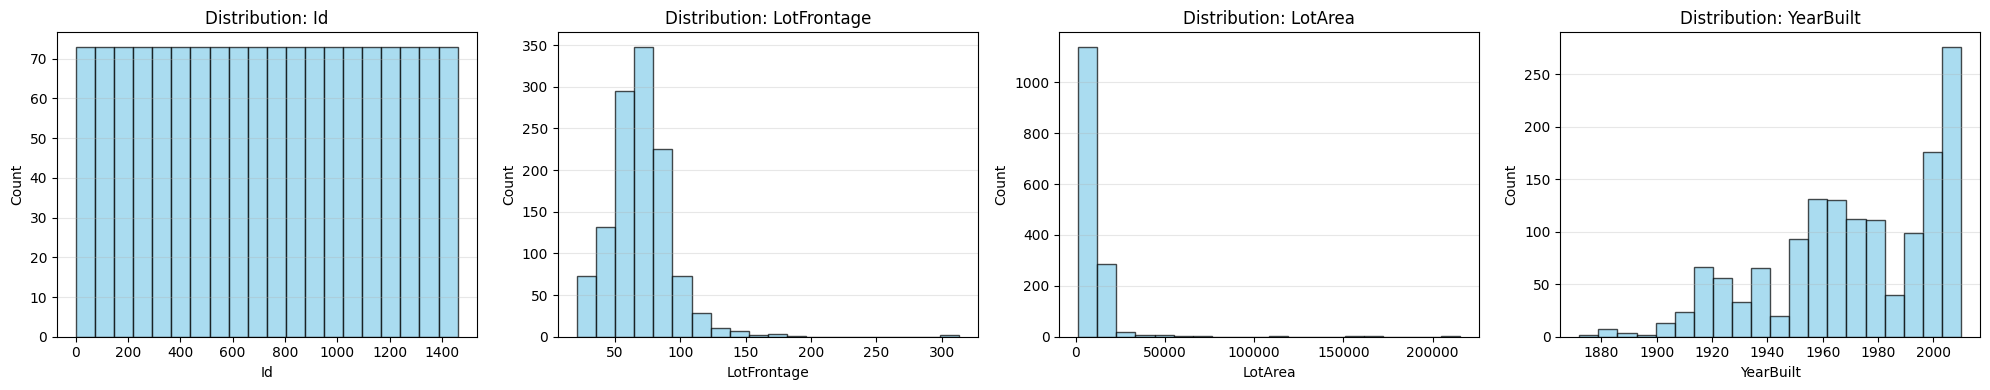

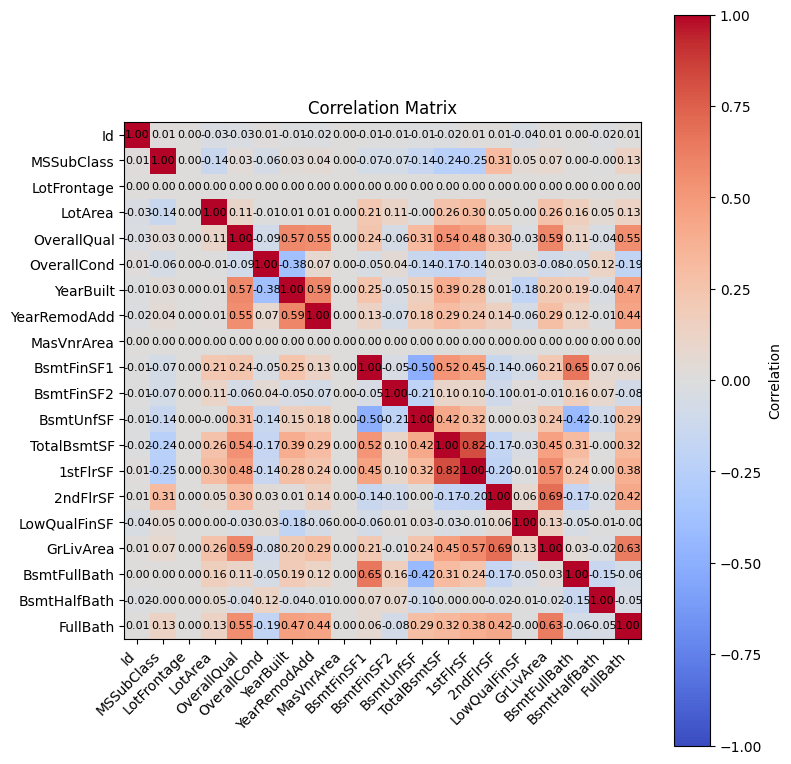

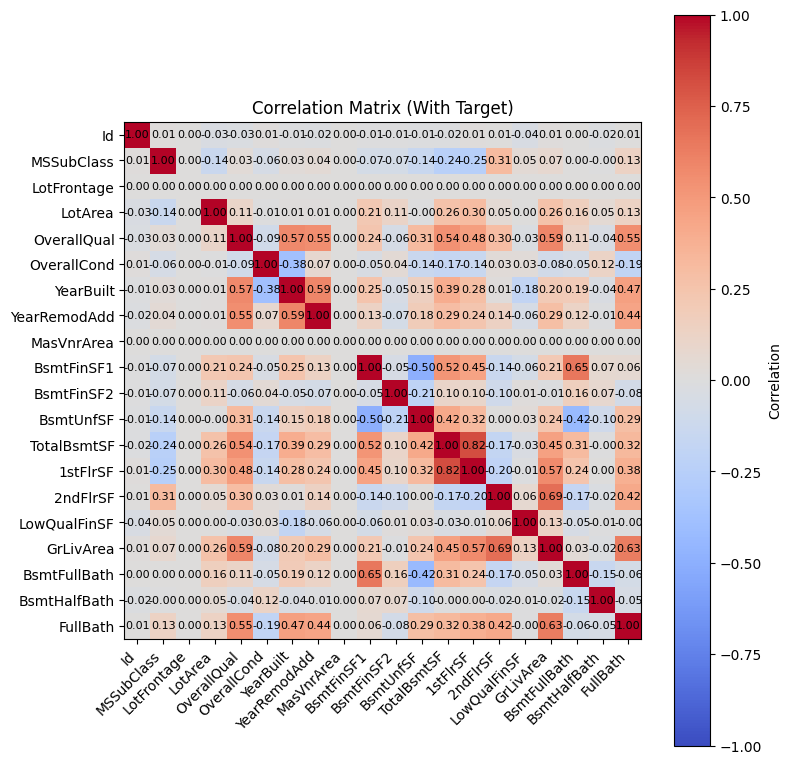

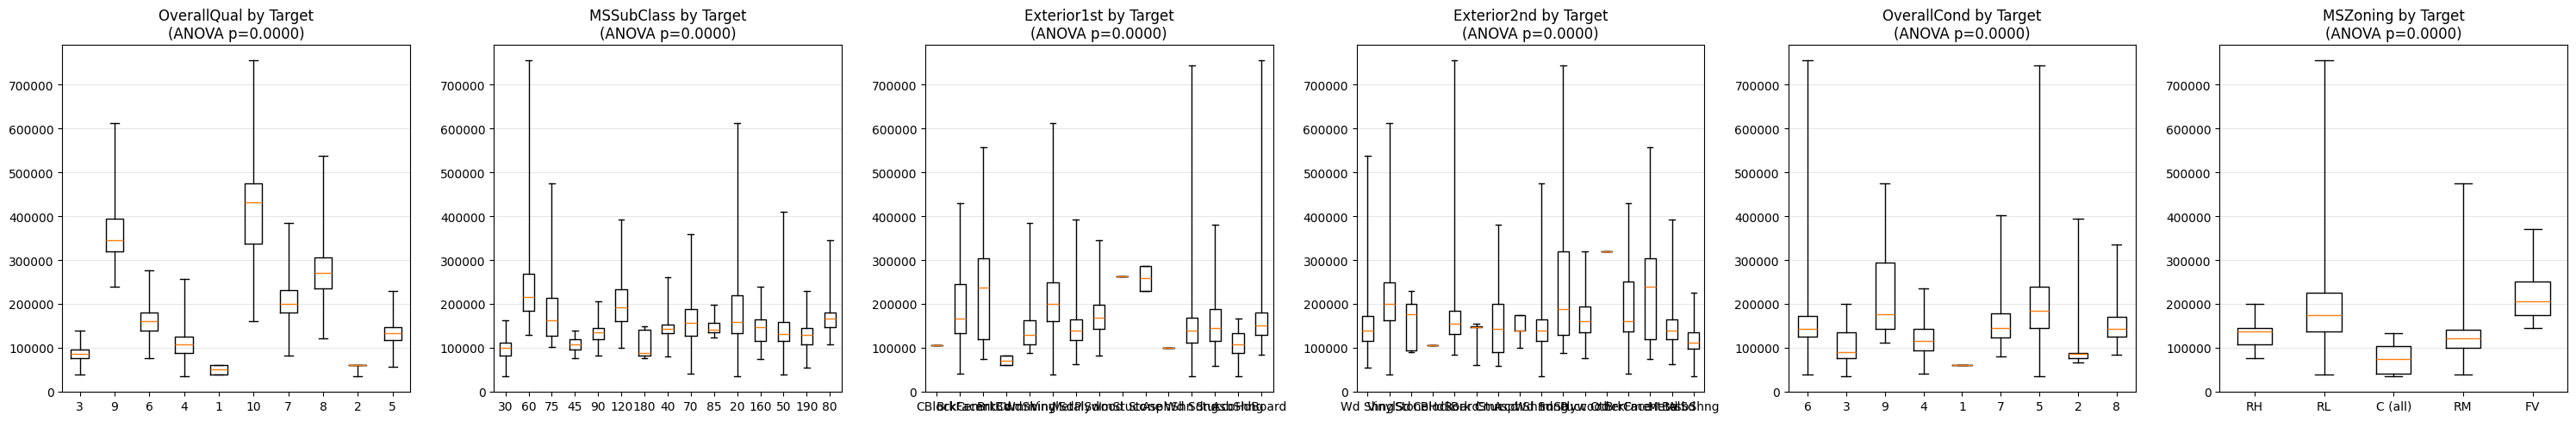

<Figure size 1000x1000 with 0 Axes>

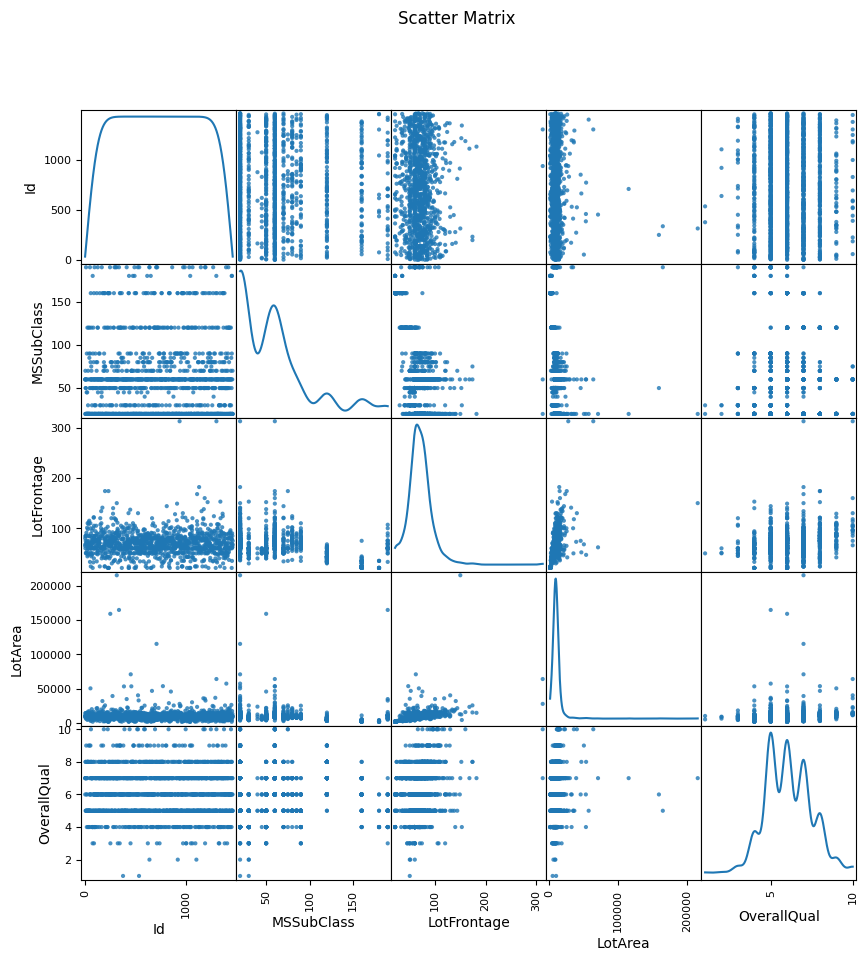

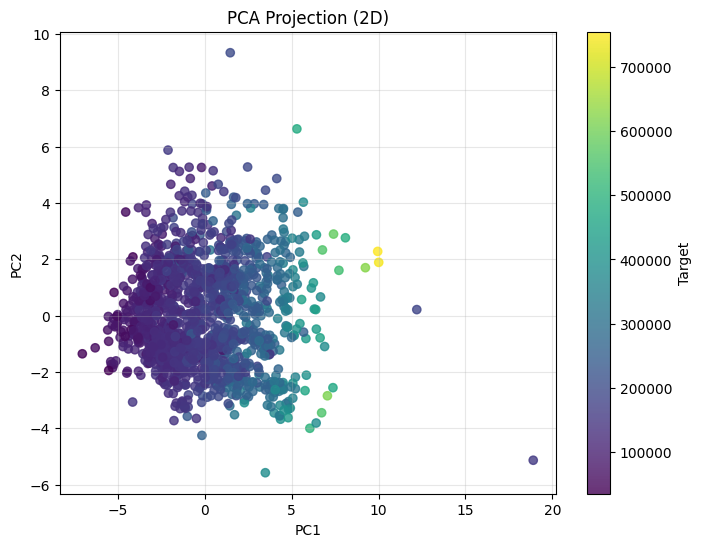

In [7]:
EDAVisualizer(profile, train).plot()

## 2. Data-quality gates with `expect_*`

Before we engineer features, a couple of lightweight sanity checks —
these are the kind of guard you'd keep in a production pipeline.

In [8]:
try:
    expect_no_nulls(train, ["SalePrice", "Id"])
    expect_value_range(train, "SalePrice", minimum=0)
    print("Data-quality gates passed.")
except ExpectationError as e:
    print("Data-quality gate failed:", e)

Data-quality gates passed.


## 3. Deep feature engineering (deterministic, pre-split)

Everything in this section is **domain knowledge applied deterministically**
(no statistic learned from the data), so it's safe to do before the
train/test split: NA-semantic recoding (many "NA"s in this dataset mean
"does not have this feature", not "unknown"), ordinal quality mappings, and
ratio/age features. Anything that *learns* from the data (imputing genuinely
unknown values, scaling, encoding nominal categories) happens **after** the
split, inside the pipeline.

In [9]:
QUALITY_MAP = {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1, None: 0}


def map_quality(col: str) -> pl.Expr:
    return pl.col(col).map_elements(lambda v: QUALITY_MAP.get(v, 0), return_dtype=pl.Int64).alias(col)


NONE_SEMANTIC_CATEGORICAL = [
    "PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu", "GarageType",
    "GarageFinish", "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1",
    "BsmtFinType2", "MasVnrType",
]
QUALITY_COLUMNS = ["ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "HeatingQC", "KitchenQual", "FireplaceQu"]


def engineer_features(df: pl.DataFrame) -> pl.DataFrame:
    df = df.with_columns(
        [pl.col(c).fill_null("None") for c in NONE_SEMANTIC_CATEGORICAL if c in df.columns]
    )
    df = df.with_columns(
        [
            pl.col("GarageYrBlt").fill_null(0),
            pl.col("MasVnrArea").fill_null(0.0),
        ]
    )
    df = df.with_columns([map_quality(c) for c in QUALITY_COLUMNS])
    df = df.with_columns(
        [
            (pl.col("TotalBsmtSF") + pl.col("1stFlrSF") + pl.col("2ndFlrSF")).alias("TotalSF"),
            (pl.col("YrSold") - pl.col("YearBuilt")).alias("HouseAge"),
            (pl.col("YrSold") - pl.col("YearRemodAdd")).alias("RemodAge"),
            (
                pl.col("FullBath")
                + 0.5 * pl.col("HalfBath")
                + pl.col("BsmtFullBath")
                + 0.5 * pl.col("BsmtHalfBath")
            ).alias("TotalBath"),
            (pl.col("PoolArea") > 0).cast(pl.Int8).alias("HasPool"),
            (pl.col("GarageArea") > 0).cast(pl.Int8).alias("HasGarage"),
            (pl.col("2ndFlrSF") > 0).cast(pl.Int8).alias("Has2ndFloor"),
            (pl.col("Fireplaces") > 0).cast(pl.Int8).alias("HasFireplace"),
            pl.col("SalePrice").log1p().alias("SalePrice_log") if "SalePrice" in df.columns else pl.lit(None),
        ]
    )
    return df


train_fe = engineer_features(train)
train_fe.select(["TotalSF", "HouseAge", "RemodAge", "TotalBath", "HasPool", "HasGarage", "SalePrice_log"]).head()

TotalSF,HouseAge,RemodAge,TotalBath,HasPool,HasGarage,SalePrice_log
i64,i64,i64,f64,i8,i8,f64
2566,5,5,3.5,0,1,12.247699
2524,31,31,2.5,0,1,12.109016
2706,7,6,3.5,0,1,12.317171
2473,91,36,2.0,0,1,11.849405
3343,8,8,3.5,0,1,12.42922


## 4. Curated feature set + leakage-safe pipeline

We select a curated ~30-column subset (numeric + a handful of informative
nominal categoricals) rather than all 81 raw columns, for notebook clarity —
the full column set is a natural "what to try next." `TrainTestSplitter` is
first, so imputation/encoding/scaling/feature-selection all fit on the
training split only.

In [10]:
NUMERIC_FEATURES = [
    "OverallQual", "OverallCond", "GrLivArea", "TotalSF", "HouseAge", "RemodAge",
    "TotalBath", "GarageArea", "GarageCars", "LotArea", "LotFrontage",
    "1stFlrSF", "TotBsmtSF" if "TotBsmtSF" in train_fe.columns else "TotalBsmtSF",
    "BedroomAbvGr", "TotRmsAbvGrd", "Fireplaces", "MasVnrArea",
    "ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "HeatingQC", "KitchenQual", "FireplaceQu",
    "HasPool", "HasGarage", "Has2ndFloor", "HasFireplace",
]
NOMINAL_FEATURES = ["Neighborhood", "MSZoning", "HouseStyle", "Foundation", "GarageType", "SaleCondition"]
FEATURES = [c for c in NUMERIC_FEATURES if c in train_fe.columns] + NOMINAL_FEATURES
TARGET = "SalePrice_log"

model_df = train_fe.select(FEATURES + [TARGET])
print(f"Final feature count: {len(FEATURES)}")
model_df.null_count().sum_horizontal()

Final feature count: 34


sum
u32
259


In [11]:
numeric_for_scaling = [c for c in NUMERIC_FEATURES if c in train_fe.columns]

base_preprocessing = [
    {
        "name": "split",
        "transformer": "TrainTestSplitter",
        "params": {"target_column": TARGET, "test_size": 0.2, "random_state": 42},
    },
    {
        "name": "impute_numeric",
        "transformer": "SimpleImputer",
        "params": {"columns": ["LotFrontage"], "strategy": "median"},
    },
    {
        "name": "encode_nominal",
        "transformer": "OneHotEncoder",
        "params": {"columns": NOMINAL_FEATURES, "drop_original": True, "handle_unknown": "ignore"},
    },
    {
        "name": "scale_numeric",
        "transformer": "StandardScaler",
        "params": {"columns": numeric_for_scaling},
    },
    {
        "name": "drop_redundant",
        "transformer": "CorrelationThreshold",
        "params": {"threshold": 0.95},
    },
]

## 5. Baseline: untuned Ridge regression

In [12]:
baseline_config = {
    "preprocessing": base_preprocessing,
    "modeling": {"type": "ridge_regression", "params": {"alpha": 1.0, "random_state": 42}},
}

baseline_pipeline = SkyulfPipeline(baseline_config)
baseline_metrics = baseline_pipeline.fit(model_df, target_column=TARGET)
print("Baseline Ridge:", baseline_metrics["modeling"])

Baseline Ridge: {'problem_type': 'regression', 'splits': {'train': ModelEvaluationReport(dataset_name='train', metrics={'mae': 0.09057477459007834, 'mse': 0.017000275648437275, 'rmse': 0.13038510516327115, 'r2': 0.888480687189847, 'mape': 0.007565122817313321, 'explained_variance': 0.888480687189847}, classification=None, regression=RegressionEvaluation(residuals=ResidualsData(predicted=[11.352927851943374, 12.165180546572364, 12.003985423024027, 11.558777749072933, 12.08126452965085, 11.811978355342081, 12.405368745236329, 11.771177283602723, 11.612127488488564, 12.837434437021429, 12.039614177648438, 11.980817333126105, 11.863621675369709, 12.298123010712732, 12.047201772555812, 12.53908732150844, 12.766133498144463, 12.083737458001334, 11.96846502049497, 11.831747917623138, 11.825762175770755, 11.852875649718472, 12.760182441182545, 11.819207293921309, 12.311834235728009, 11.788771787156566, 11.533806483124248, 12.140057335417277, 11.855000691371757, 11.865002212635217, 12.008958283

## 6. Tuned Ridge regression

The same preprocessing, but the modeling step is wrapped in the pipeline's
built-in `hyperparameter_tuner` (random search over `alpha`, 5-fold CV).

In [13]:
tuned_config = {
    "preprocessing": base_preprocessing,
    "modeling": {
        "type": "hyperparameter_tuner",
        "base_model": {"type": "ridge_regression"},
        "strategy": "random",
        "metric": "neg_root_mean_squared_error",
        "n_trials": 20,
        "cv_folds": 5,
        "cv_type": "k_fold",
        "search_space": {"alpha": [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]},
        "random_state": 42,
    },
}

tuned_pipeline = SkyulfPipeline(tuned_config)
tuned_metrics = tuned_pipeline.fit(model_df, target_column=TARGET)
print("Tuned Ridge:", tuned_metrics["modeling"])

Tuned Ridge: {'problem_type': 'regression', 'splits': {'train': ModelEvaluationReport(dataset_name='train', metrics={'mae': 0.09083171179772265, 'mse': 0.01730673394814444, 'rmse': 0.1315550605189494, 'r2': 0.8864703657282974, 'mape': 0.007586648562738425, 'explained_variance': 0.8864703657282974}, classification=None, regression=RegressionEvaluation(residuals=ResidualsData(predicted=[11.368448868932008, 12.16659080488778, 12.021081377931191, 11.537005230328294, 12.095385579646328, 11.814048282810015, 12.409184037338562, 11.7704233071456, 11.590010934735115, 12.82975433385207, 12.026184137313198, 11.977071765133228, 11.86281111536114, 12.313273310081026, 12.056451542302835, 12.534034757483084, 12.774926698222766, 12.08082746792207, 11.973838212452675, 11.842419943258582, 11.824807365852163, 11.84797001355061, 12.677525464126823, 11.826553498484538, 12.314775033319009, 11.78512059635997, 11.525040106531183, 12.163220201092695, 11.853445607088373, 11.880066779503355, 11.999723728315004, 

/Users/BH7043/Skyulf/.venv/lib/python3.12/site-packages/sklearn/model_selection/_search.py:324: UserWarning: The total space of parameters 8 is smaller than n_iter=20. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


## 7. A tree-based comparison: Gradient Boosting

In [14]:
gbr_config = {
    "preprocessing": base_preprocessing,
    "modeling": {
        "type": "gradient_boosting_regressor",
        "params": {"n_estimators": 300, "max_depth": 3, "learning_rate": 0.05, "random_state": 42},
    },
}

gbr_pipeline = SkyulfPipeline(gbr_config)
gbr_metrics = gbr_pipeline.fit(model_df, target_column=TARGET)
print("Gradient Boosting:", gbr_metrics["modeling"])

Gradient Boosting: {'problem_type': 'regression', 'splits': {'train': ModelEvaluationReport(dataset_name='train', metrics={'mae': 0.056154019658419846, 'mse': 0.00538608229903851, 'rmse': 0.07338993322682962, 'r2': 0.964668090732816, 'mape': 0.004685858699031018, 'explained_variance': 0.964668090732816}, classification=None, regression=RegressionEvaluation(residuals=ResidualsData(predicted=[11.338271881315515, 12.147785758671153, 11.954676848070356, 11.6211274669683, 12.12250035526771, 11.751759189519964, 12.465068249767814, 11.721351132862088, 11.37960703787375, 12.914232930371725, 11.883160764320817, 11.938365887275701, 11.692235461476555, 12.196486844961647, 12.090252441076421, 12.462875868540737, 12.747993633835254, 12.066723090162197, 12.03390560532245, 11.91333408200771, 11.890910241396833, 11.837767226010488, 12.84884338268542, 11.819638030208504, 12.43853552734639, 11.708578642930194, 11.673309641473413, 12.23926165753287, 11.914210856905306, 11.93626693029761, 12.0065382863348

## 8. Compare (back-transformed to real dollars)

We fit on `log1p(SalePrice)`; RMSE/R^2 in metrics are in log space. To make
the comparison intuitive, we report an approximate RMSE in dollars too, using
`expm1` on the held-out predictions.

In [26]:
def summarize(name, metrics):
    m = metrics["modeling"].get("test", metrics["modeling"])
    print(f"{name:20s} R2={m.get('r2', float('nan')):.4f}  RMSE(log)={m.get('rmse', float('nan')):.4f}")


for name, metrics in [
    ("Baseline Ridge", baseline_metrics),
    ("Tuned Ridge", tuned_metrics),
    ("Gradient Boosting", gbr_metrics),
]:
    summarize(name, metrics)

Baseline Ridge       R2=nan  RMSE(log)=nan
Tuned Ridge          R2=nan  RMSE(log)=nan
Gradient Boosting    R2=nan  RMSE(log)=nan


## Key takeaways

- A public Kaggle "good" score on this competition is roughly RMSE(log) in
  the **0.11-0.13** range on the leaderboard (top ~25-50%); getting into the
  top 50 typically needs heavier ensembling/stacking across many model
  families plus more exhaustive feature engineering than shown here.
- What to try next: full 81-column feature set, target encoding for
  high-cardinality categoricals (`TargetEncoder`/`WOEEncoder`), a
  `voting_regressor`/`stacking_regressor` blending Ridge + GBM + a
  regularized linear model, and Optuna-strategy tuning with more trials.
- This notebook intentionally favors clarity over leaderboard-chasing —
  every step is inspectable and leakage-safe by construction.